In [1]:
import glob
import epi_utils as eu
from tqdm.auto import tqdm

import matplotlib as mpl
import matplotlib.pyplot as plt

In [2]:
import numpy as np
import pandas as pd
import holoviews as hv
import hvplot.pandas
import hvplot.dask

hvplot.extension('matplotlib')

In [3]:
data_path = "dataset/gene_count/"

In [4]:
file_list = []
file_list.append(glob.glob(f"{data_path}*.csv"))
flat_file_list = eu.flatten_concatenation(file_list)
display(flat_file_list)

['dataset/gene_count\\chr1.csv',
 'dataset/gene_count\\chr10.csv',
 'dataset/gene_count\\chr11.csv',
 'dataset/gene_count\\chr12.csv',
 'dataset/gene_count\\chr13.csv',
 'dataset/gene_count\\chr14.csv',
 'dataset/gene_count\\chr15.csv',
 'dataset/gene_count\\chr16.csv',
 'dataset/gene_count\\chr17.csv',
 'dataset/gene_count\\chr18.csv',
 'dataset/gene_count\\chr19.csv',
 'dataset/gene_count\\chr2.csv',
 'dataset/gene_count\\chr20.csv',
 'dataset/gene_count\\chr21.csv',
 'dataset/gene_count\\chr22.csv',
 'dataset/gene_count\\chr3.csv',
 'dataset/gene_count\\chr4.csv',
 'dataset/gene_count\\chr5.csv',
 'dataset/gene_count\\chr6.csv',
 'dataset/gene_count\\chr7.csv',
 'dataset/gene_count\\chr8.csv',
 'dataset/gene_count\\chr9.csv',
 'dataset/gene_count\\chrMT.csv',
 'dataset/gene_count\\chrUn.csv',
 'dataset/gene_count\\chrX.csv',
 'dataset/gene_count\\chrY.csv',
 'dataset/gene_count\\gene_count.csv']

In [ ]:
data = []

for filename in tqdm(flat_file_list):
    print(f"Processing file: {filename}")
    df = pd.read_csv(filename)
    data.append(df)

df_out = pd.concat(data, axis=0, ignore_index=False)
df_out.to_csv(f"{data_path}gene_count.csv", index=False)

## Load data using Dask

In [5]:
import dask.dataframe as dd

In [6]:
gene_dask = dd.read_csv(f"{data_path}gene_count.csv")
display(gene_dask.head())

,Chromosome,Source,Feature,Start,End,Score,Strand,Frame,gene_id,transcript_id,gene_name,exon_number,exon_id,tss,histone_count,gene_count
0,chr1,ncbiRefSeq.2021-05-17,transcript,249230769,249231298,.,+,.,RPL23AP25,RPL23AP25,RPL23AP25,NaN,NaN,249230769,0,0
1,chr1,ncbiRefSeq.2021-05-17,exon,249230769,249231298,.,+,.,RPL23AP25,RPL23AP25,RPL23AP25,1.0,RPL23AP25.1,249230769,0,0
2,chr1,ncbiRefSeq.2021-05-17,transcript,249206890,249206992,.,-,.,RNU6-1205P,RNU6-1205P,RNU6-1205P,NaN,NaN,249206992,0,1
3,chr1,ncbiRefSeq.2021-05-17,exon,249206890,249206992,.,-,.,RNU6-1205P,RNU6-1205P,RNU6-1205P,1.0,RNU6-1205P.1,249206992,0,1
4,chr1,ncbiRefSeq.2021-05-17,transcript,249200433,249213345,.,+,.,PGBD2,NM_001017434.2,PGBD2,NaN,NaN,249200433,13,0


In [7]:
display(gene_dask.head())
display(gene_dask.shape)

,Chromosome,Source,Feature,Start,End,Score,Strand,Frame,gene_id,transcript_id,gene_name,exon_number,exon_id,tss,histone_count,gene_count
0,chr1,ncbiRefSeq.2021-05-17,transcript,249230769,249231298,.,+,.,RPL23AP25,RPL23AP25,RPL23AP25,NaN,NaN,249230769,0,0
1,chr1,ncbiRefSeq.2021-05-17,exon,249230769,249231298,.,+,.,RPL23AP25,RPL23AP25,RPL23AP25,1.0,RPL23AP25.1,249230769,0,0
2,chr1,ncbiRefSeq.2021-05-17,transcript,249206890,249206992,.,-,.,RNU6-1205P,RNU6-1205P,RNU6-1205P,NaN,NaN,249206992,0,1
3,chr1,ncbiRefSeq.2021-05-17,exon,249206890,249206992,.,-,.,RNU6-1205P,RNU6-1205P,RNU6-1205P,1.0,RNU6-1205P.1,249206992,0,1
4,chr1,ncbiRefSeq.2021-05-17,transcript,249200433,249213345,.,+,.,PGBD2,NM_001017434.2,PGBD2,NaN,NaN,249200433,13,0


(<dask_expr.expr.Scalar: expr=ReadCSV(3d73900).size() / 16, dtype=float64>, 16)

:Scatter   [tss]   (histone_count)
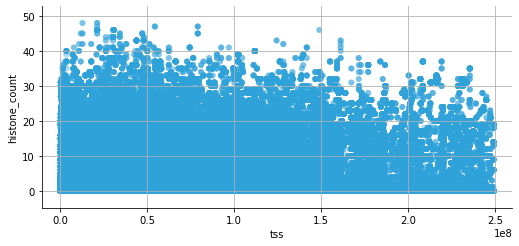

In [8]:
# Plot the tss and histone count
# gene_dask.hvplot(x='tss', y='histone_count', kind='scatter', alpha=0.4, grid=True).opts(default_tools=["pan"]) # Bokeh backend

gene_dask.hvplot(x='tss', y='histone_count', kind='scatter', alpha=0.4, grid=True)

:Scatter   [tss]   (gene_count)
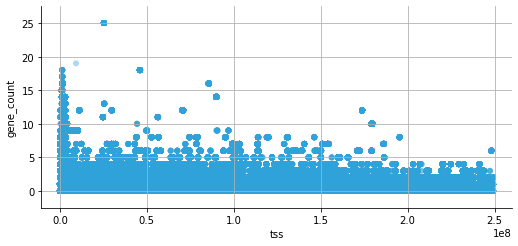

In [9]:
# Plot the tss and gene count
# gene_dask.hvplot(x='tss', y='gene_count', kind='scatter', alpha=0.4, grid=True).opts(default_tools=["pan"])
gene_dask.hvplot(x='tss', y='gene_count', kind='scatter', alpha=0.4, grid=True)

:Scatter   [histone_count]   (gene_count)
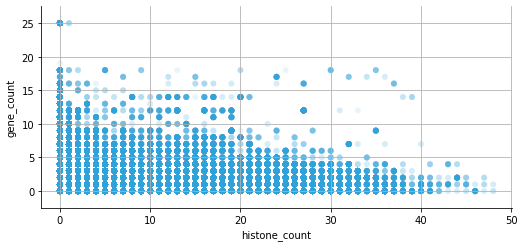

In [10]:
# Plot the histone peak count and gene count
# gene_dask.hvplot(x='gene_count', y='histone_count', kind='scatter', alpha=0.1, grid=True).opts(default_tools=["pan"])
gene_dask.hvplot(x='histone_count', y='gene_count', kind='scatter', alpha=0.1, grid=True)